In [3]:
import shap
import joblib
import pandas as pd

In [13]:
# Load trained model
churn_model = joblib.load("../src/models/churn_model.pkl")

print("Model loaded")

Model loaded


In [14]:
# Load dataset
customer_churn_data = pd.read_excel("../data/raw/telco_churn.xlsx")

customer_churn_data.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [16]:
# Columns to remove (target, leakage, IDs, location)
columns_to_remove = [
    "Churn Value",
    "Churn Label",
    "Churn Score",
    "Churn Reason",
    "CLTV",
    "CustomerID",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Count",
]

# Separate features (X)
feature_data = customer_churn_data.drop(columns=columns_to_remove)

feature_data.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3


In [17]:
# Load saved encoders
categorical_encoders = joblib.load("../src/models/label_encoders.pkl")

print("Encoders loaded")

Encoders loaded


In [18]:
# Apply encoders to categorical columns
for column_name in feature_data.columns:

    if column_name in categorical_encoders:

        encoder = categorical_encoders[column_name]

        # Transform text to numbers
        feature_data[column_name] = encoder.transform(
            feature_data[column_name].astype(str)
        )

feature_data.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges
0,1,No,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15
1,0,No,0,1,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65
2,0,No,0,1,8,1,2,1,0,0,2,0,2,2,0,1,2,99.65,820.5
3,0,No,1,1,28,1,2,1,0,0,2,2,2,2,0,1,2,104.80,3046.05
4,1,No,0,1,49,1,2,1,0,2,2,0,2,2,0,1,0,103.70,5036.3


In [19]:
# Convert all to numeric
feature_data = feature_data.apply(pd.to_numeric, errors="coerce")

# Fill NaN values with 0
feature_data = feature_data.fillna(0)

feature_data.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges
0,1,0.0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15
1,0,0.0,0,1,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65
2,0,0.0,0,1,8,1,2,1,0,0,2,0,2,2,0,1,2,99.65,820.50
3,0,0.0,1,1,28,1,2,1,0,0,2,2,2,2,0,1,2,104.80,3046.05
4,1,0.0,0,1,49,1,2,1,0,2,2,0,2,2,0,1,0,103.70,5036.30


In [20]:
# Create SHAP explainer for tree-based model
explainer = shap.TreeExplainer(churn_model)

print("Explainer created")

Explainer created


In [22]:
# Generate SHAP values (missing shap_values variable)
shap_values = explainer.shap_values(feature_data)

print("SHAP values calculated")

SHAP values calculated


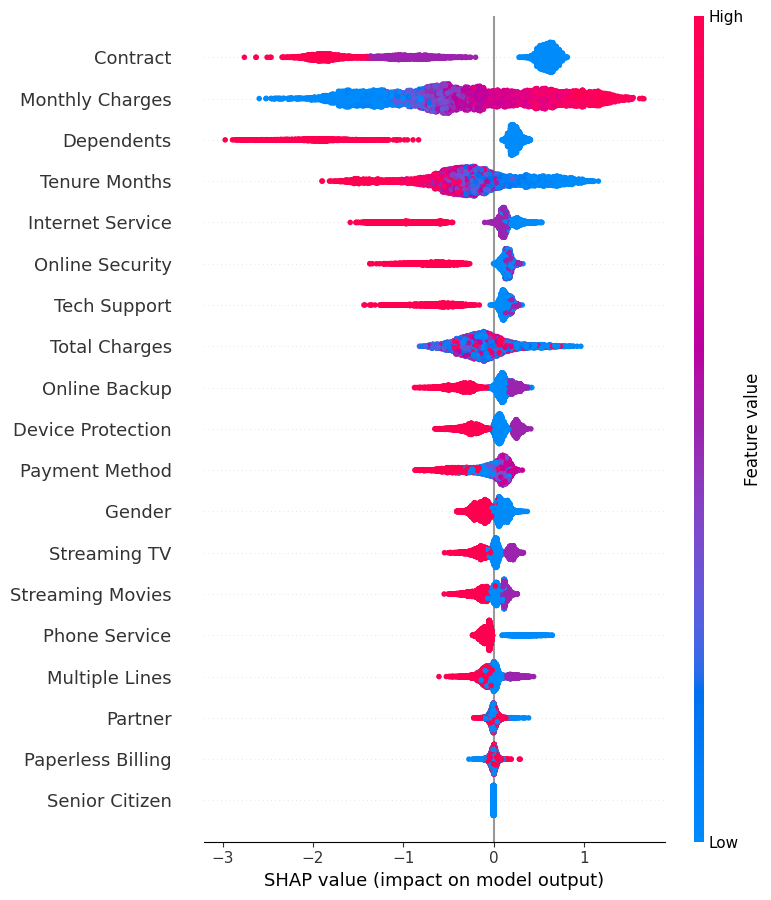

In [21]:
# Plot SHAP summary
shap.summary_plot(shap_values, feature_data)  # This variable is not defined yet